In [1]:
import numpy as np
import hyperspy.api as hs

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib_scalebar.scalebar import ScaleBar
import colorcet as cc

In [3]:
from scipy.ndimage import rotate

In [4]:
%matplotlib widget

In [5]:
dp_300k = hs.load('/Users/nihy/Desktop/Working Data/EuAl4/Good Data/SAED/Temp Dependence/300K.dm4')
dp_100k = hs.load('/Users/nihy/Desktop/Working Data/EuAl4/Good Data/SAED/Temp Dependence/100K.dm4')
dp_5k = hs.load('/Users/nihy/Desktop/Working Data/EuAl4/Good Data/SAED/Temp Dependence/5K.dm4')

In [6]:
dp_300k.axes_manager, dp_5k.axes_manager

(<Axes manager, axes: (|4096, 4096)>
             Name |   size |  index |  offset |   scale |  units 
 ================ | ====== | ====== | ======= | ======= | ====== 
 ---------------- | ------ | ------ | ------- | ------- | ------ 
                x |   4096 |      0 |      -0 |   0.012 |   1/nm 
                y |   4096 |      0 |      -0 |   0.012 |   1/nm ,
 <Axes manager, axes: (|4096, 4096)>
             Name |   size |  index |  offset |   scale |  units 
 ================ | ====== | ====== | ======= | ======= | ====== 
 ---------------- | ------ | ------ | ------- | ------- | ------ 
                x |   4096 |      0 |      -0 |   0.013 |   1/nm 
                y |   4096 |      0 |      -0 |   0.013 |   1/nm )

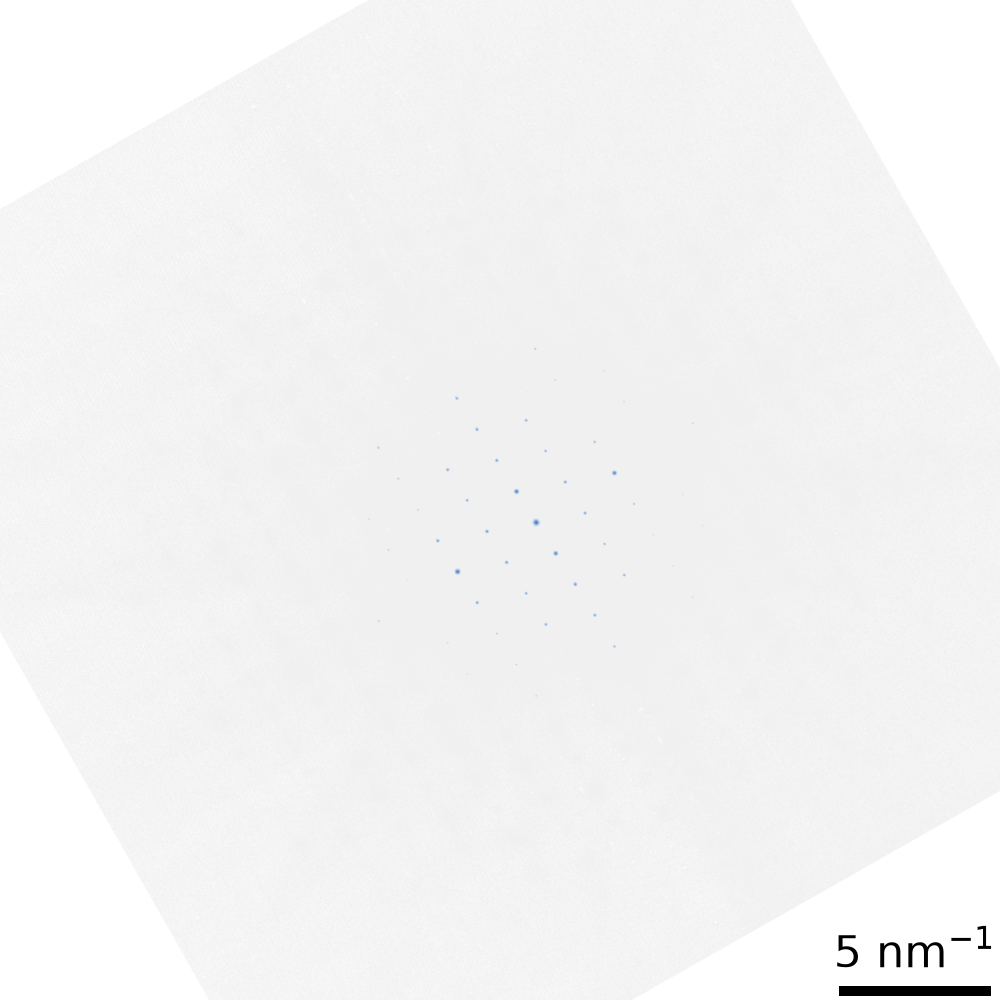

In [7]:
plt.figure(figsize = (10, 10))
plt.subplots_adjust(0,0,1,1)
plt.imshow(rotate(dp_300k.data, 90+29.6,reshape = False), cmap=cc.cm.blues, norm='log', vmin = 3e3)
plt.axis("off")
sbar = ScaleBar(0.016/2,
                "1/nm",
                dimension = "si-length-reciprocal", 
                location = 'lower right', 
                frameon = False,
                color = 'k',
                scale_loc = 'top',
                font_properties = {'size': 32})
ax = plt.gca()
ax.add_artist(sbar)
#plt.savefig('/Users/nihy/Desktop/Working Data/CsV3Sb5/SAED/300K_OneView.svg', dpi=300, bbox_inches='tight', pad_inches=0)

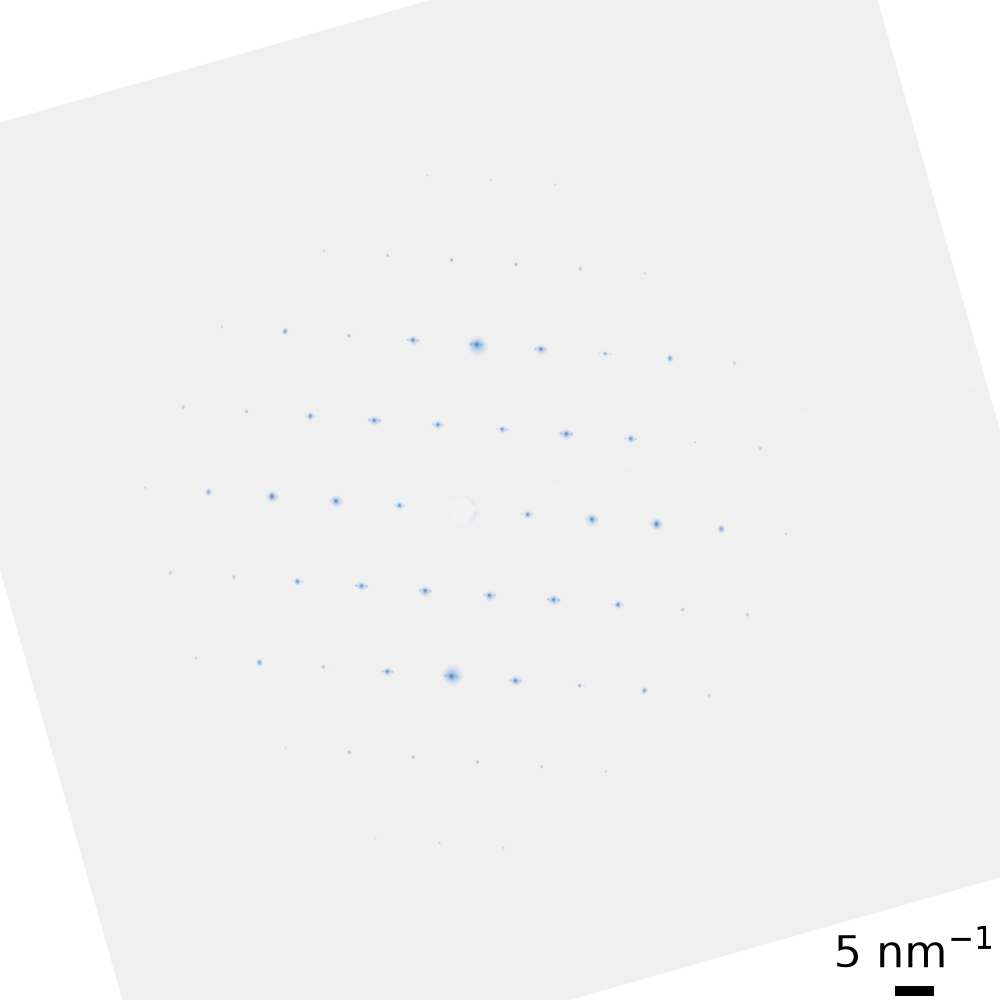

In [8]:
plt.figure(figsize = (10, 10))
plt.subplots_adjust(0,0,1,1)
plt.imshow(rotate(dp_5k.data, -164.14+90,reshape = False), cmap=cc.cm.blues, norm='log', vmin = 1e5, vmax = 1e7)
plt.axis("off")
sbar = ScaleBar(0.063/2,
                "1/nm",
                fixed_value = 5,
                dimension = "si-length-reciprocal", 
                location = 'lower right', 
                frameon = False,
                color = 'k',
                scale_loc = 'top',
                font_properties = {'size': 32})
ax = plt.gca()
ax.add_artist(sbar)
#plt.savefig('/Users/nihy/Desktop/Working Data/CsV3Sb5/SAED/5K_stela.svg', dpi=300, bbox_inches='tight', pad_inches=0)

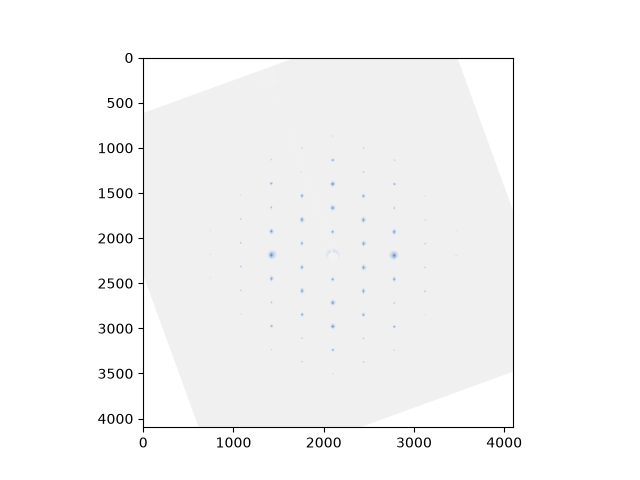

In [9]:
plt.figure()
plt.imshow(rotate(dp_5k.data, 20,reshape = False), cmap=cc.cm.blues, norm='log', vmin=7e4)

In [10]:
line_profile_5k = rotate(dp_5k.data, 20,reshape = False)[2194 - 100: 2194 + 100, 2780 -5 : 2780 + 5].mean(1)
line_profile_100k = rotate(dp_100k.data, -66.1,reshape = False)[2120 - 100: 2120 + 100, 2586 -5 : 2586 + 5].mean(1)
line_profile_300k = rotate(dp_300k.data, 87,reshape = False)[2207 - 100: 2207 + 100, 2502 -5 : 2502 + 5].mean(1)

In [15]:
x = np.arange(-100, 100)*0.013/2
x1 = np.arange(-100, 100)*0.012/2

In [16]:
n_lines = 400
cmap = mpl.colormaps['plasma']

# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1, 400))

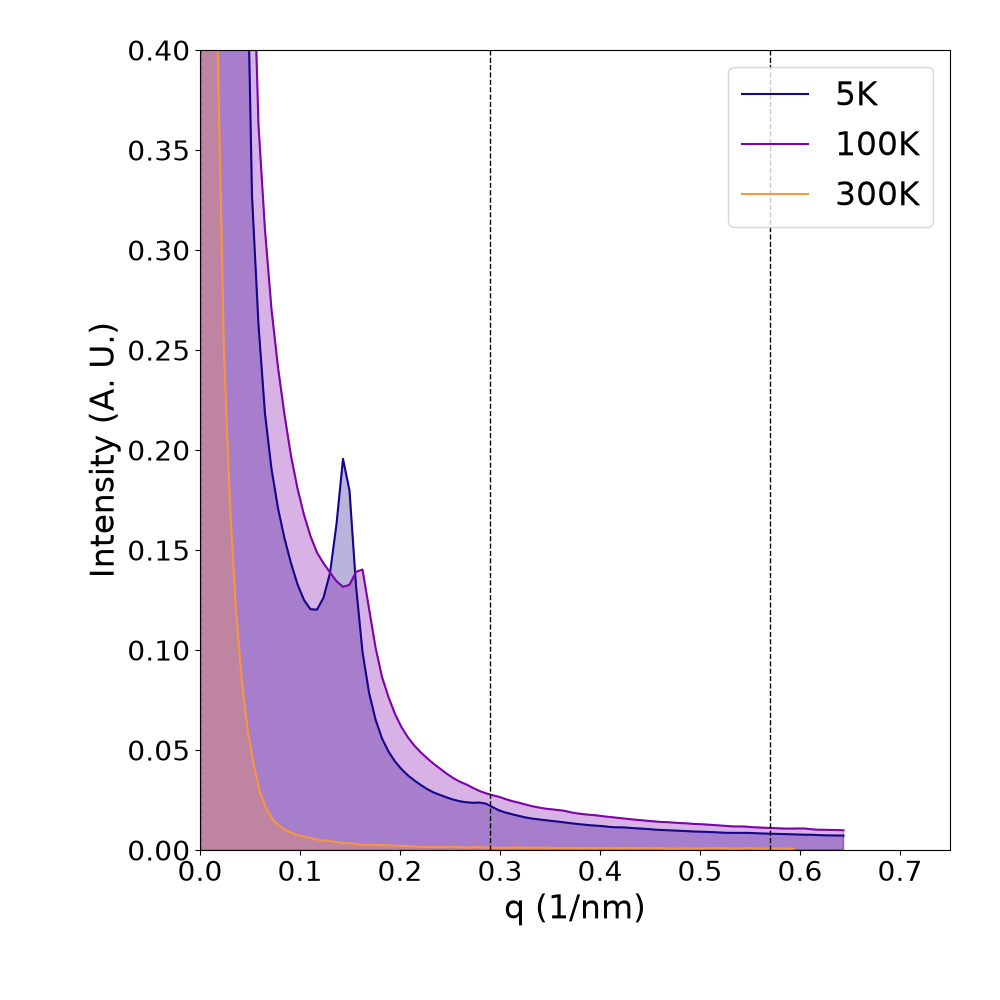

In [17]:
plt.figure(figsize = (10, 10))
plt.subplots_adjust(0.2, 0.15, 0.95, 0.95)
plt.plot(x, line_profile_5k/line_profile_5k.max(), label='5K', color = colors[5])
plt.fill_between(x, line_profile_5k/line_profile_5k.max(), alpha=0.3, color = colors[5])
plt.plot(x, line_profile_100k/line_profile_100k.max(), label='100K', color = colors[100])
plt.fill_between(x, line_profile_100k/line_profile_100k.max(), alpha=0.3, color = colors[100])
plt.plot(x1, line_profile_300k/line_profile_300k.max(), label='300K', color = colors[300])
plt.fill_between(x1, line_profile_300k/line_profile_300k.max(), alpha=0.3, color = colors[300])

plt.legend(fontsize = 24)
plt.xlim(0, 0.75)
plt.ylim(0, 0.4)
plt.xlabel('q (1/nm)', fontsize = 24)
plt.ylabel('Intensity (A. U.)', fontsize = 24)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.vlines([0, 0.29, 0.57], 0, 0.4, color = 'k', ls = '--', lw = 1)

#plt.savefig('/Users/nihy/Desktop/Working Data/EuAl4/Good Data/SAED/intensity_200.svg', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)

<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_45444/2924998133.py:15: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('$I\cdot q^2$', fontsize = 32)


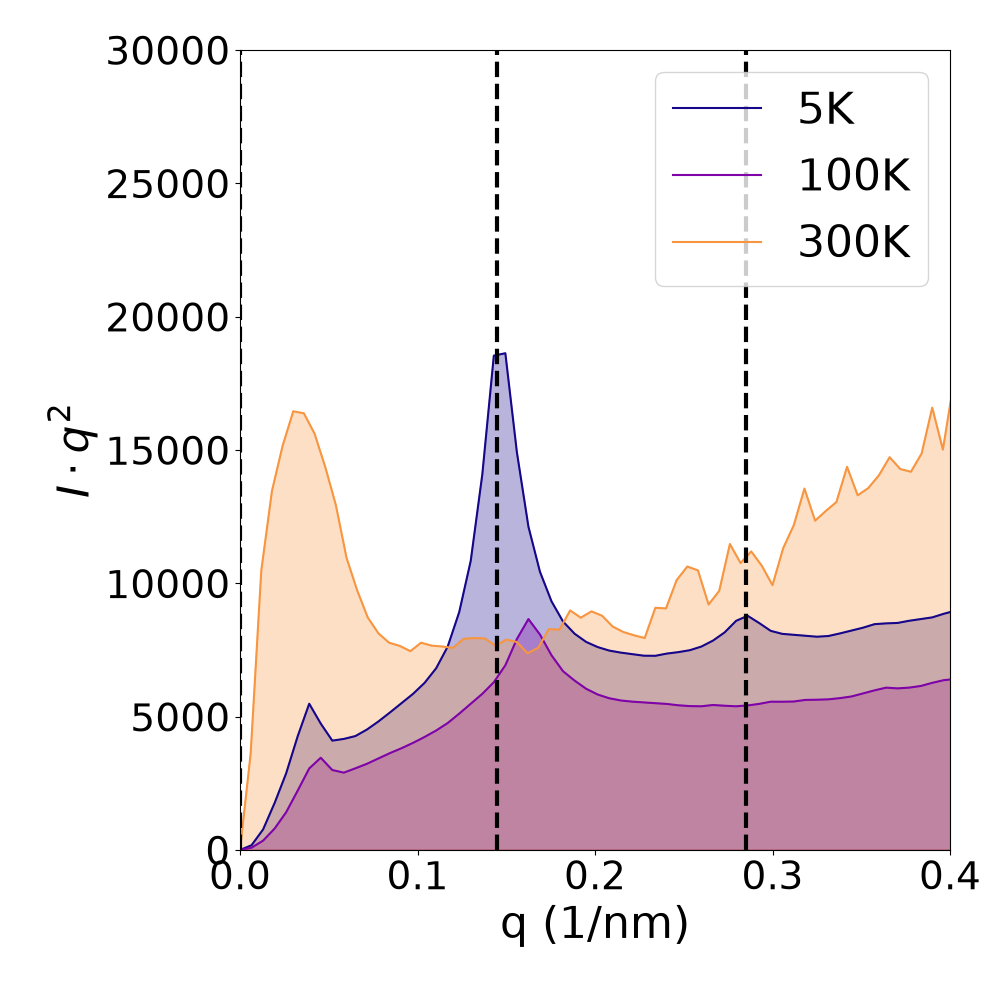

In [24]:
plt.figure(figsize = (10, 10))
plt.subplots_adjust(0.24, 0.15, 0.95, 0.95)
plt.plot(x, line_profile_5k*x**2, label='5K', color = colors[5])
plt.fill_between(x, line_profile_5k*x**2, alpha=0.3, color = colors[5])
plt.plot(x, line_profile_100k*x**2, label='100K', color = colors[100])
plt.fill_between(x, line_profile_100k*x**2, alpha=0.3, color = colors[100])
plt.plot(x1, line_profile_300k*500*x1**2, label='300K', color = colors[300])
plt.fill_between(x1, line_profile_300k*500*x1**2, alpha=0.3, color = colors[300])


plt.legend(fontsize = 32)
plt.xlim(0, 0.4)
plt.ylim(0, 3e4)
plt.xlabel('q (1/nm)', fontsize = 32)
plt.ylabel('$I\cdot q^2$', fontsize = 32)
plt.tick_params(axis='both', which='major', labelsize=28)
plt.vlines([0, 0.29/2, 0.57/2], 0, 1e6, color = 'k', ls = '--', lw = 3)
plt.savefig('/Users/nihy/Desktop/Working Data/EuAl4/Good Data/SAED/intensity_q2_200.svg', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)